# 🖼️ Introduction to Convolutional Neural Networks (CNN)

## Overview
This notebook contains an introductory deep learning exercise completed during the AI Bootcamp. The project introduces the fundamental concepts of Convolutional Neural Networks (CNNs) and demonstrates how convolutional layers can be used for image classification tasks.

## Objective
The objective of this exercise is to understand the architecture of CNNs and implement a convolutional neural network using TensorFlow and Keras for image classification.

## Skills Practiced

- Convolutional Neural Networks (CNN)
- Convolution and Pooling Layers
- Feature Extraction
- Image Classification
- Model Training
- Model Evaluation

---
**Tools:** Python, NumPy, TensorFlow, Keras

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
dfTrain = pd.read_csv("fashion_train.csv")

In [4]:
# First 5 rows of train data
dfTrain.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Reading Test Data
dfTest = pd.read_csv("fashion_test.csv")

In [7]:
# First 5 rows of test data
dfTest.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
Y_train = dfTrain.label
X_train = dfTrain.drop(["label"], axis=1)
X_test = dfTest.drop(["label"], axis=1)
Y_test = dfTest.label

C:\Users\MY-PC\AppData\Local\Temp\ipykernel_4220\2057248265.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(Y_train, palette="terrain")


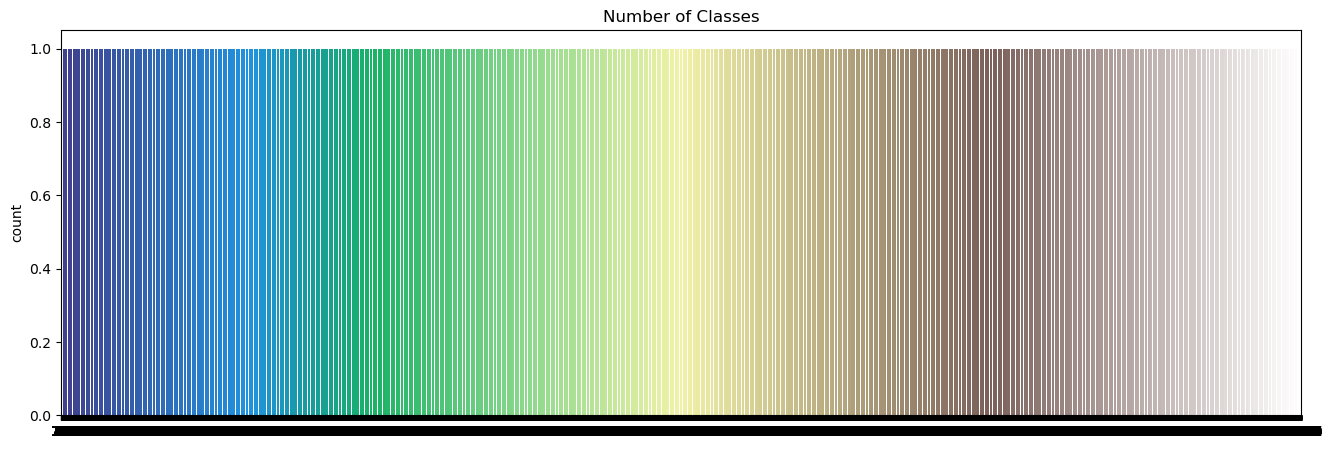

In [9]:
plt.figure(figsize=(16,5))
sns.countplot(Y_train, palette="terrain")
plt.title("Number of Classes")
plt.show()

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برخی از تصاویر را نمایش دهید تا با مجموعه تصاویر بیشتر آشنا شوید.


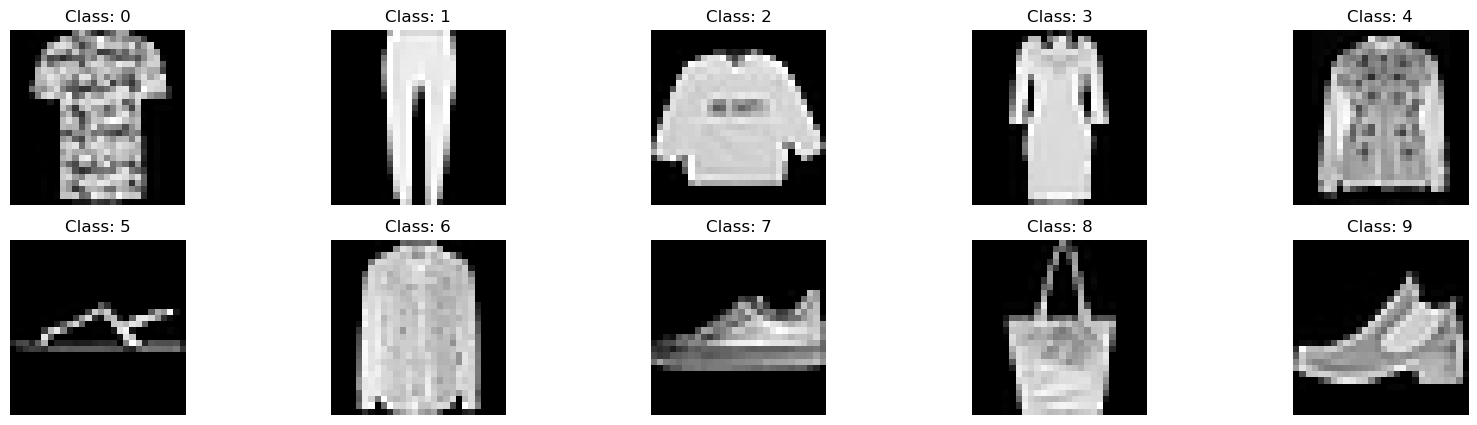

In [10]:
plt.figure(figsize=(20,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    img = dfTrain[dfTrain.label==i].iloc[0,1:].values
    img = img.reshape((28,28))
    plt.imshow(img, cmap='gray')
    plt.title("Class: " + str(i))
    plt.axis('off')

plt.show()

In [11]:
# Normalization
X_train = X_train / 255.0
X_test = X_test / 255.0

In [12]:
X_train = X_train.values.reshape(-1,28,28,1)
X_test = X_test.values.reshape(-1,28,28,1)

print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)

X_train Shape:  (60000, 28, 28, 1)
X_test Shape:  (10000, 28, 28, 1)


In [14]:
from tensorflow.keras.utils import to_categorical

Y_train = to_categorical(Y_train, num_classes=10)

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(X_train, Y_train, test_size=0.3, random_state=42)

print("x_train shape",x_train.shape)
print("x_test shape",x_val.shape)
print("y_train shape",y_train.shape)
print("y_test shape",y_val.shape)

x_train shape (42000, 28, 28, 1)
x_test shape (18000, 28, 28, 1)
y_train shape (42000, 10)
y_test shape (18000, 10)


In [21]:
from sklearn.metrics import confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [22]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

C:\Users\MY-PC\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False)

In [25]:
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [26]:
epochs = 50
batchSize = 300

In [27]:
# Data Augmentation
datagen = ImageDataGenerator(
        featurewise_center=False,
        samplewise_center=False,
        featurewise_std_normalization=False,
        samplewise_std_normalization=False,
        zca_whitening=False,
        rotation_range=10,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        vertical_flip=False)

datagen.fit(x_train)

In [29]:
cnn = model.fit(
    datagen.flow(x_train, y_train, batch_size=batchSize),
    epochs=epochs,
    validation_data=(x_val, y_val),
    steps_per_epoch=x_train.shape[0] // batchSize
)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.5944 - loss: 1.0960 - val_accuracy: 0.7481 - val_loss: 0.6437
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.7256 - loss: 0.7237 - val_accuracy: 0.7851 - val_loss: 0.5356
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.7516 - loss: 0.6444 - val_accuracy: 0.8034 - val_loss: 0.4881
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7746 - loss: 0.5889 - val_accuracy: 0.8248 - val_loss: 0.4592
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7893 - loss: 0.5574 - val_accuracy: 0.8464 - val_loss: 0.4140
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.8000 - loss: 0.5293 - val_accuracy: 0.8532 - val_loss: 0.3954
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.8145 - loss: 0.5024 - val_accuracy: 0.8573 - val_loss: 0.3767
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.8191 - loss: 0.4815 - val_acc

In [31]:
print("Accuracy after fitting: {:.2f}%".format(cnn.history['accuracy'][-1]*100))

Accuracy after fitting: 89.06%


In [32]:
Y_test = to_categorical(Y_test, num_classes=10)

In [33]:
score = model.evaluate(X_test, Y_test)
print("Test Loss: {:.4f}".format(score[0]))
print("Test Accuracy: {:.2f}%".format(score[1]*100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9163 - loss: 0.2174
Test Loss: 0.2174
Test Accuracy: 91.63%


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


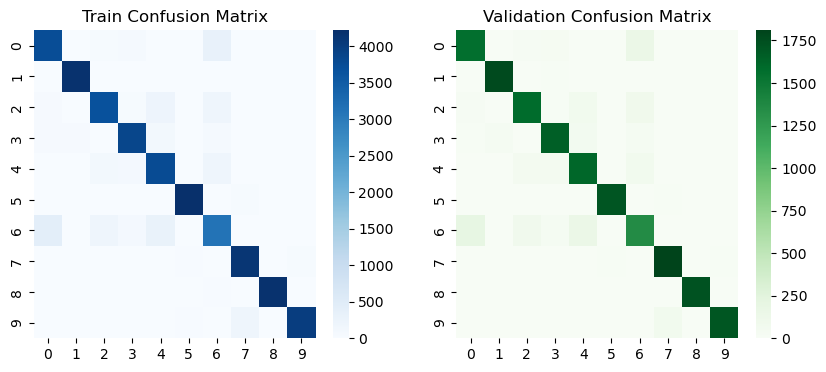

In [34]:
y_train_pred = model.predict(x_train)
y_val_pred = model.predict(x_val)

cm_train = confusion_matrix(np.argmax(y_train,axis=1), np.argmax(y_train_pred,axis=1))
cm_val = confusion_matrix(np.argmax(y_val,axis=1), np.argmax(y_val_pred,axis=1))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm_train, annot=False, cmap="Blues")
plt.title("Train Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_val, annot=False, cmap="Greens")
plt.title("Validation Confusion Matrix")

plt.show()